In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

#install.packages("tibble")
#install.packages("dplyr")
#install.packages(ggplot2)
#install.packages("caret")
#install.packages("glmnet")

library(tibble)
library(dplyr)
library(ggplot2)
library(caret)
library(pROC)
library(ROSE)
library(glmnet)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: lattice
Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var

Loaded ROSE 0.0-4

Loading required package: Matrix
Loaded glmnet 4.1-8
In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages


In [3]:
%%R
# Defining GMIDs for Blue Routes
# Am creating a list of GMIDs for processing
blue_route_gmIDs  <- c(
    "20f0b890-ec64-11ee-b297-3b0ad9d5d6c6",
"39ba7438-d0d5-11ee-9435-f7e542e2436c",
"ba28b352-ec8f-11ee-b297-3b0ad9d5d6c6",
"cf6fdf3a-eaa3-11ee-b297-3b0ad9d5d6c6",
"57d240d6-ea4d-11ee-b297-3b0ad9d5d6c6",
"cb205756-ec43-11ee-b297-3b0ad9d5d6c6",
"90101c36-a621-11ee-88ec-eb6a8d5269b4",
"71a18322-ecab-11ee-b297-3b0ad9d5d6c6",
"326699c2-ecd8-11ee-b297-3b0ad9d5d6c6",
"75f83e28-eb77-11ee-b297-3b0ad9d5d6c6",
"88180f82-ed4f-11ee-9385-ef789ffde1d3",
"f6ac3c82-a445-11ee-88ec-eb6a8d5269b4",
"c7c02bda-ebe0-11ee-b297-3b0ad9d5d6c6",
"b224ef9c-ec10-11ee-b297-3b0ad9d5d6c6",
"c335d84c-a45c-11ee-88ec-eb6a8d5269b4",
"60546ef4-edaa-11ee-9385-ef789ffde1d3",
"59c189d8-ed54-11ee-9385-ef789ffde1d3",
"af10e22a-ebb1-11ee-b297-3b0ad9d5d6c6",
"9830d896-d2dc-11ee-b437-336917683bb8",
"5976b77a-a504-11ee-88ec-eb6a8d5269b4",
"c0624e24-d9aa-11ee-a158-97f8443fd730",
"8b6a6cfc-ed6d-11ee-9385-ef789ffde1d3",
"e2079a78-dc1d-11ee-a158-97f8443fd730",
"3a2a78cc-db21-11ee-a158-97f8443fd730",
"feaf2ba8-d28d-11ee-b437-336917683bb8",
"aa86a660-dc05-11ee-a158-97f8443fd730",
"e6d7d384-db40-11ee-a158-97f8443fd730",
"ed7f2038-ea1e-11ee-b297-3b0ad9d5d6c6",
"04151804-ec20-11ee-b297-3b0ad9d5d6c6",
"64bbe8e0-eb94-11ee-b297-3b0ad9d5d6c6",
"64737d98-d312-11ee-b437-336917683bb8",
"dc39aa14-db32-11ee-a158-97f8443fd730",
"f671c05c-a5e4-11ee-88ec-eb6a8d5269b4",
"d94ef300-ed60-11ee-9385-ef789ffde1d3",
"20cbfe8c-ea2b-11ee-b297-3b0ad9d5d6c6",
"58263e34-a45c-11ee-88ec-eb6a8d5269b4",
"e9d67bf2-ec35-11ee-b297-3b0ad9d5d6c6",
"f9d62032-db2a-11ee-a158-97f8443fd730",
"82d39c74-ea59-11ee-b297-3b0ad9d5d6c6",
"7228e03a-ebf0-11ee-b297-3b0ad9d5d6c6",
"25d3bdc8-ecbc-11ee-b297-3b0ad9d5d6c6",
"fc119dfc-eb67-11ee-b297-3b0ad9d5d6c6",
"c9023e32-ed90-11ee-9385-ef789ffde1d3",
"64875cc0-d054-11ee-9435-f7e542e2436c",
"5fcc4fd8-ea71-11ee-b297-3b0ad9d5d6c6",
"d1d090d4-ea7c-11ee-b297-3b0ad9d5d6c6",
"559495ca-d270-11ee-b437-336917683bb8",
"21376e38-ec01-11ee-b297-3b0ad9d5d6c6",
"b76f33be-ea61-11ee-b297-3b0ad9d5d6c6",
"3ea96640-ea37-11ee-b297-3b0ad9d5d6c6",
"f0bcec4e-ed3e-11ee-9385-ef789ffde1d3",
"17876fec-ea66-11ee-b297-3b0ad9d5d6c6",
"e269948a-ed9d-11ee-9385-ef789ffde1d3",
"a17c1280-ea10-11ee-b297-3b0ad9d5d6c6",
"530de03a-ed79-11ee-9385-ef789ffde1d3",
"68c289fa-dbd4-11ee-a158-97f8443fd730",
"0f4f0a06-ea98-11ee-b297-3b0ad9d5d6c6",
"7613801a-edcb-11ee-9385-ef789ffde1d3",
"76683d3c-db18-11ee-a158-97f8443fd730",
"80340ab8-d054-11ee-9435-f7e542e2436c",
"6d62da08-ec9d-11ee-b297-3b0ad9d5d6c6",
"7f09f6c6-a5b0-11ee-88ec-eb6a8d5269b4",
"6af236d6-d98f-11ee-a158-97f8443fd730",
"70060810-eb59-11ee-b297-3b0ad9d5d6c6",
"3d2a80f0-ec81-11ee-b297-3b0ad9d5d6c6",
"3343fd3c-eb87-11ee-b297-3b0ad9d5d6c6",
"df8e3742-ec54-11ee-b297-3b0ad9d5d6c6",
"286c70cc-d2f7-11ee-b437-336917683bb8",
"e8a8b2be-edbf-11ee-9385-ef789ffde1d3",
"baf0e4be-bede-11ee-835b-599066b5eb60",
"513a670c-eea9-11ee-9385-ef789ffde1d3",
"3441fc36-ecca-11ee-b297-3b0ad9d5d6c6",
"2bc6ebb8-a529-11ee-88ec-eb6a8d5269b4",
"154fab12-a43f-11ee-88ec-eb6a8d5269b4",
"43914d48-ed85-11ee-9385-ef789ffde1d3",
"ba6e1072-9524-11ee-956e-9da2d070324c",
"4d0254fc-ec73-11ee-b297-3b0ad9d5d6c6",
"2d35c522-eba2-11ee-b297-3b0ad9d5d6c6",
"787d9684-d2c2-11ee-b437-336917683bb8",
"3ce8a358-edd8-11ee-9385-ef789ffde1d3",
"06cbdbc0-db4d-11ee-a158-97f8443fd730",
"8c57e8ac-dbec-11ee-a158-97f8443fd730",
"c8f54ac0-ebd2-11ee-b297-3b0ad9d5d6c6",
"acd71bc0-ecf4-11ee-9385-ef789ffde1d3",
"69ab88ec-dc17-11ee-a158-97f8443fd730",
"19b7ebd0-d9b7-11ee-a158-97f8443fd730",
"5240e750-ec30-11ee-b297-3b0ad9d5d6c6",
"a7c98b32-ebc2-11ee-b297-3b0ad9d5d6c6",
"721a9830-ece6-11ee-b297-3b0ad9d5d6c6",
"47561998-d9c3-11ee-a158-97f8443fd730",
"04115e66-ea91-11ee-b297-3b0ad9d5d6c6",
"aef91c4a-ede5-11ee-9385-ef789ffde1d3",
"a253145a-d2a6-11ee-b437-336917683bb8",
"36663b02-ea87-11ee-b297-3b0ad9d5d6c6",
"5f6573ba-ed2f-11ee-9385-ef789ffde1d3",
"d62ee6e8-ed02-11ee-9385-ef789ffde1d3",
"da853e0c-a10f-11ee-981c-d126ddbe9afa"
)

In [4]:
%%R
# Define the base directory for preprocessed data
base_path <- "/home/gampadu_linux/Desktop/TDMprivate/Preprocessed_Moving_Data_v2/2sec_moving_window"

# List all files in the directory
all_files <- list.files(base_path, full.names = FALSE)

# Extract gmIDs from filenames (remove ".csv" extension)
existing_gmIDs <- sub("\\.csv$", "", all_files)

# Find gmIDs that exist in the directory
matching_gmIDs <- intersect(blue_route_gmIDs, existing_gmIDs)

# Find gmIDs that are missing
missing_gmIDs <- setdiff(blue_route_gmIDs, existing_gmIDs)

# Display results
print(paste("Total files found:", length(existing_gmIDs)))
print(paste("Matching gmIDs:", length(matching_gmIDs)))
print(paste("Missing gmIDs:", length(missing_gmIDs)))

# Display first 10 missing gmIDs
print("Missing gmIDs (first 10):")
print(head(missing_gmIDs, 10))

[1] "Total files found: 247"
[1] "Matching gmIDs: 97"
[1] "Missing gmIDs: 0"
[1] "Missing gmIDs (first 10):"
character(0)


In [5]:
%%R

# Check if a specific file exists
print(file.exists(file.path(base_path, existing_gmIDs[1])))

# List files inside a GMID folder
print(list.files(file.path(base_path, existing_gmIDs[1]), full.names = TRUE))

[1] TRUE
[1] "/home/gampadu_linux/Desktop/TDMprivate/Preprocessed_Moving_Data_v2/2sec_moving_window/01e65360-efd4-11ee-b966-fb353e7798cd/01e65360-efd4-11ee-b966-fb353e7798cd.csv"


In [6]:
%%R
# Read first available CSV file
file_path <- list.files(file.path(base_path, matching_gmIDs[1]), pattern = "\\.csv$", full.names = TRUE)
temp_data <- read.csv(file_path[1])

# Display column names
print(names(temp_data))

 [1] "Ind"                         "groupMetadataID"            
 [3] "time"                        "NormalizedTime"             
 [5] "BinaryDrivingMode"           "BinaryDisengagement"        
 [7] "BinaryDisengagementExpanded" "DisengagementID"            
 [9] "DisengagementExpandedID"     "latitude"                   
[11] "longitude"                   "ProgressAlongRoute"         
[13] "solStatus"                   "solType"                    
[15] "extendedSolutionStatus"      "numSatsInSolution"          
[17] "speedMps_mean"               "Acceleration_mean"          
[19] "brakePercentage_mean"        "throttlePercentage_mean"    
[21] "steeringPercentage_mean"     "LatLonTotalStdDev_mean"     


In [7]:
%%R
valid_files <- c()  # Store GMIDs that contain the required columns

for (id in matching_gmIDs) {
    file_path <- list.files(file.path(base_path, id), pattern = "\\.csv$", full.names = TRUE)
    
    if (length(file_path) > 0) {  # Ensure at least one file exists
        temp_data <- read.csv(file_path[1])  # Read first file
        
        # Check if required column exists
        if ("LatLonTotalStdDev_mean" %in% names(temp_data)) {
            valid_files <- c(valid_files, id)
        }
    }
}

# Print results
print(paste("Number of GMIDs that contain required columns:", length(valid_files)))

[1] "Number of GMIDs that contain required columns: 97"


In [8]:
%%R
# Initialize an empty tibble to store merged data
df_merged <- tibble()

# Loop through only valid GMIDs and read CSV files
for (id in valid_files) {
    file_path <- list.files(file.path(base_path, id), pattern = "\\.csv$", full.names = TRUE)
    
    if (length(file_path) > 0) {
        temp_data <- read.csv(file_path[1])  # Read first CSV file
        
        # Append to merged dataset
        df_merged <- bind_rows(df_merged, temp_data)
    }
}

In [9]:
%%R
# Check for missing data
colSums(is.na(df_merged))

# Check class balance for BinaryDisengagementExpanded
table(df_merged$BinaryDisengagementExpanded)


      0       1 
5418702   39414 


In [11]:
%%R
# Load required library
library(dplyr)

# Define training and testing GMIDs based on red_route_gmIDs
training_gmIDs <- blue_route_gmIDs[1:92]  # First 92 GMIDs for training
testing_gmIDs <- blue_route_gmIDs[(length(blue_route_gmIDs)-4):length(blue_route_gmIDs)]  # Last 5 GMIDs for testing

# Filter df_merged for training and testing data based on GMIDs
train_data <- df_merged %>% filter(groupMetadataID %in% training_gmIDs)
test_data <- df_merged %>% filter(groupMetadataID %in% testing_gmIDs)

# Check the number of rows in each dataset
print(paste("Training data rows:", nrow(train_data)))
print(paste("Testing data rows:", nrow(test_data)))

# Verify if test_data is empty
if (nrow(test_data) == 0) {
    print("Error: test_data is empty. Check GMID filtering.")
}

[1] "Training data rows: 5160985"
[1] "Testing data rows: 297131"


In [12]:
%%R
# Train a Logistic Regression Model using BinaryDisengagementExpanded
model <- glm(
  BinaryDisengagementExpanded ~ speedMps_mean + throttlePercentage_mean + brakePercentage_mean + steeringPercentage_mean + LatLonTotalStdDev_mean,
  data = train_data,
  family = binomial
)

# Display model summary
summary(model)


Call:
glm(formula = BinaryDisengagementExpanded ~ speedMps_mean + throttlePercentage_mean + 
    brakePercentage_mean + steeringPercentage_mean + LatLonTotalStdDev_mean, 
    family = binomial, data = train_data)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.1334  -0.1170  -0.1076  -0.1042   3.6246  

Coefficients:
                          Estimate Std. Error  z value Pr(>|z|)    
(Intercept)             -5.4546164  0.0146672 -371.891  < 2e-16 ***
speedMps_mean            0.0144021  0.0009096   15.834  < 2e-16 ***
throttlePercentage_mean  0.0041523  0.0006371    6.518 7.14e-11 ***
brakePercentage_mean     0.0347572  0.0003905   89.014  < 2e-16 ***
steeringPercentage_mean -0.0157689  0.0005060  -31.165  < 2e-16 ***
LatLonTotalStdDev_mean   0.0580019  0.0018156   31.947  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 446269  on 5160984  degrees of freed

In [14]:
%%R
# Predict on the test set
predictions <- predict(model, test_data, type = "response")

# Convert probabilities to binary classes (0 or 1)
predicted_classes <- ifelse(predictions > 0.5, 1, 0)

# Calculate accuracy
accuracy <- mean(predicted_classes == test_data$BinaryDisengagementExpanded)

# Print the accuracy
print(paste("Accuracy:", accuracy))

[1] "Accuracy: 0.994312273037818"


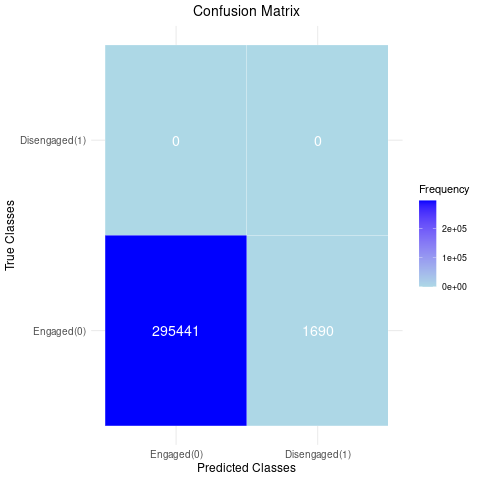

In [15]:
%%R
# Load required libraries
library(ggplot2)
library(caret)

# Map the values to labels (1 -> "Disengaged", 0 -> "Engaged")
predicted_classes_labeled <- factor(predicted_classes, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))
actual_classes_labeled <- factor(test_data$BinaryDisengagementExpanded, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))

# Generate the confusion matrix
cm <- confusionMatrix(predicted_classes_labeled, actual_classes_labeled)
cm_table <- as.data.frame(cm$table)

# Rename columns for better understanding
colnames(cm_table) <- c("Actual", "Predicted", "Frequency")

# Create the colored confusion matrix plot
ggplot(cm_table, aes(x = Predicted, y = Actual, fill = Frequency)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightblue", high = "blue", name = "Frequency") +
  geom_text(aes(label = Frequency), color = "white", size = 5) +
  labs(title = "Confusion Matrix", x = "Predicted Classes", y = "True Classes") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 14),
        axis.title = element_text(size = 12),
        axis.text = element_text(size = 10))

In [16]:
%%R
table(train_data$BinaryDisengagementExpanded)
table(test_data$BinaryDisengagementExpanded)


     0      1 
295441   1690 


In [17]:
%%R
library(caret)

# Convert the response variable to a factor
train_data$BinaryDisengagementExpanded <- as.factor(train_data$BinaryDisengagementExpanded)

# Downsample the majority class (0s) to match the minority class (1s)
set.seed(42)
train_data_balanced <- downSample(
  x = train_data[, c("speedMps_mean", "throttlePercentage_mean", "brakePercentage_mean", "steeringPercentage_mean", "LatLonTotalStdDev_mean")], 
  y = train_data$BinaryDisengagementExpanded
)

# Check new distribution
table(train_data_balanced$Class)  # Should be balanced now


    0     1 
37724 37724 


In [18]:
%%R
# Rename 'Class' back to 'BinaryDisengagementExpanded'
train_data_balanced$BinaryDisengagementExpanded <- train_data_balanced$Class
train_data_balanced$Class <- NULL  # Optionally remove the 'Class' column

# Now you can train your model
model <- glm(
  BinaryDisengagementExpanded ~ speedMps_mean + throttlePercentage_mean + 
    brakePercentage_mean + steeringPercentage_mean + LatLonTotalStdDev_mean,
  data = train_data_balanced,
  family = binomial
)

summary(model)


Call:
glm(formula = BinaryDisengagementExpanded ~ speedMps_mean + throttlePercentage_mean + 
    brakePercentage_mean + steeringPercentage_mean + LatLonTotalStdDev_mean, 
    family = binomial, data = train_data_balanced)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-6.0620  -1.0470  -0.2427   1.1938   1.8099  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -0.4222127  0.0202089 -20.892  < 2e-16 ***
speedMps_mean            0.0017432  0.0013288   1.312     0.19    
throttlePercentage_mean  0.0034865  0.0008849   3.940 8.15e-05 ***
brakePercentage_mean     0.0332728  0.0006514  51.077  < 2e-16 ***
steeringPercentage_mean -0.0141083  0.0007462 -18.908  < 2e-16 ***
LatLonTotalStdDev_mean   0.2161202  0.0105233  20.537  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 104593  on 75447  degrees of freed

In [19]:
%%R
# Predict on the test set using the trained model
predictions <- predict(model, test_data, type = "response")

# Convert probabilities to binary classes (0 or 1)
predicted_classes <- ifelse(predictions > 0.5, 1, 0)

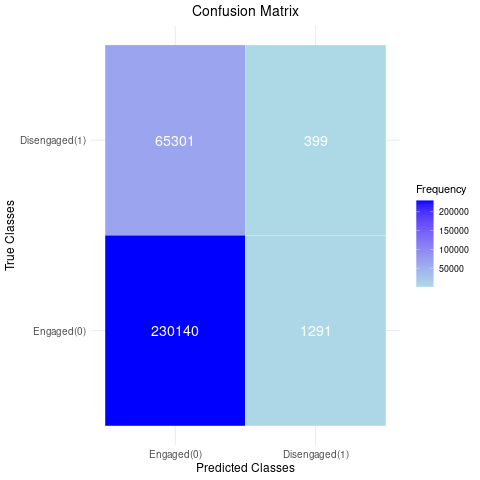

In [20]:
%%R
# Load required libraries
library(ggplot2)
library(caret)

# Convert actual and predicted values into factors for labeling
predicted_classes_labeled <- factor(predicted_classes, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))
actual_classes_labeled <- factor(test_data$BinaryDisengagementExpanded, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))

# Generate the confusion matrix
cm <- confusionMatrix(predicted_classes_labeled, actual_classes_labeled)
cm_table <- as.data.frame(cm$table)  # Convert to dataframe for visualization

# Rename columns for clarity
colnames(cm_table) <- c("Actual", "Predicted", "Frequency")

# Create the colored confusion matrix plot
ggplot(cm_table, aes(x = Predicted, y = Actual, fill = Frequency)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightblue", high = "blue", name = "Frequency") +
  geom_text(aes(label = Frequency), color = "white", size = 5) +
  labs(title = "Confusion Matrix", x = "Predicted Classes", y = "True Classes") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10)
  )

In [21]:
%%R
# Manually calculating the confusion matrix values
TP <- 366  # True Positives
FP <- 1291     # False Positives
FN <- 65301  # False Negatives
TN <- 230140    # True Negatives

# Calculate Metrics
accuracy <- (TP + TN) / (TP + TN + FP + FN)  # Overall correctness
precision <- TP / (TP + FP)                  # Precision (Positive Predictive Value)
recall <- TP / (TP + FN)                     # Recall (Sensitivity)
f1_score <- 2 * ((precision * recall) / (precision + recall))  # F1-score

# Print Metrics
cat("Accuracy:", round(accuracy, 4), "\n")  
cat("Precision:", round(precision, 4), "\n")  
cat("Recall:", round(recall, 4), "\n")  
cat("F1-score:", round(f1_score, 4), "\n")  

Accuracy: 0.7759 
Precision: 0.2209 
Recall: 0.0056 
F1-score: 0.0109 


In [22]:
%%R
# Filter actual disengagement locations (Ground Truth)
actual_disengaged <- test_data[test_data$BinaryDisengagementExpanded == 1, ]

# Extract actual disengagement coordinates
actual_latitudes <- actual_disengaged$latitude
actual_longitudes <- actual_disengaged$longitude

# Filter test data where the model predicted Disengagement (1)
predicted_disengaged <- test_data[predicted_classes == 1, ]

# Extract predicted disengagement coordinates
predicted_latitudes <- predicted_disengaged$latitude
predicted_longitudes <- predicted_disengaged$longitude

# Ensure both actual and predicted lists have the same length
min_length <- min(length(actual_latitudes), length(predicted_latitudes))
actual_latitudes <- actual_latitudes[1:min_length]
actual_longitudes <- actual_longitudes[1:min_length]
predicted_latitudes <- predicted_latitudes[1:min_length]
predicted_longitudes <- predicted_longitudes[1:min_length]

# Create a data frame with actual and predicted disengagement locations
disengagement_comparison <- data.frame(
    actual_latitude = actual_latitudes,
    actual_longitude = actual_longitudes,
    predicted_latitude = predicted_latitudes,
    predicted_longitude = predicted_longitudes
)

# Display first few rows to verify
head(disengagement_comparison)

  actual_latitude actual_longitude predicted_latitude predicted_longitude
1        39.32938        -82.10702           39.32402           -82.10438
2        39.32938        -82.10702           39.32402           -82.10437
3        39.32938        -82.10702           39.32402           -82.10437
4        39.32938        -82.10702           39.32402           -82.10437
5        39.32938        -82.10702           39.32402           -82.10437
6        39.32938        -82.10702           39.32402           -82.10437


In [23]:
%%R
head(disengagement_comparison)
dim(disengagement_comparison)

[1] 1690    4


In [24]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd

# Activate the conversion between R and pandas
pandas2ri.activate()

# Convert R dataframe to Pandas dataframe
disengagement_comparison_py = ro.conversion.rpy2py(ro.r('disengagement_comparison'))

# Verify if it's a Pandas DataFrame now
print(type(disengagement_comparison_py))  # Should output <class 'pandas.core.frame.DataFrame'>
print(disengagement_comparison_py.shape)  # Check shape
print(disengagement_comparison_py.head()) # Check first few rows

<class 'pandas.core.frame.DataFrame'>
(1690, 4)
   actual_latitude  actual_longitude  predicted_latitude  predicted_longitude
1        39.329379        -82.107024           39.324023           -82.104375
2        39.329379        -82.107024           39.324023           -82.104375
3        39.329379        -82.107024           39.324023           -82.104375
4        39.329379        -82.107024           39.324023           -82.104375
5        39.329379        -82.107024           39.324023           -82.104375


(1690, 4)


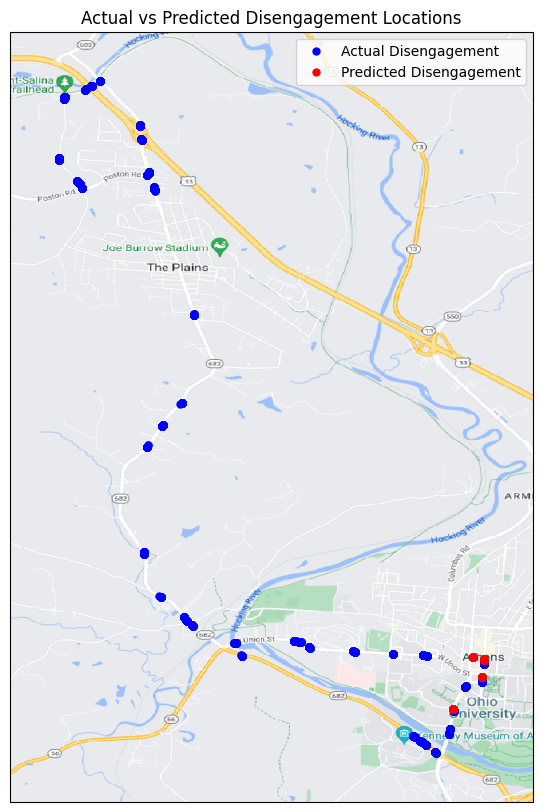

In [25]:
import cartopy.crs as ccrs
from cartopy.io.img_tiles import GoogleTiles
import matplotlib.pyplot as plt

# Define the dataframe for clarity
df = disengagement_comparison_py  

# Print shape for verification
print(df.shape)

# Define plot size
plt.figure(figsize=(10, 10))

# Get min and max latitude and longitude
minLat = df['actual_latitude'].min()
maxLat = df['actual_latitude'].max()
minLon = df['actual_longitude'].min()
maxLon = df['actual_longitude'].max()

# Define expansion coefficient to avoid edge cutoff
expansion_coeff = 0.005

# Load street map
street_map = GoogleTiles(style='street')

# Create plot with the street map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [minLon - expansion_coeff, maxLon + expansion_coeff, 
     minLat - expansion_coeff, maxLat + expansion_coeff],
    crs=ccrs.PlateCarree()
)

# Add map image
ax.add_image(street_map, 14)

# Extract actual and predicted disengagement locations
true_disengage_lat = df['actual_latitude']
true_disengage_lon = df['actual_longitude']

pred_disengage_lat = df['predicted_latitude']
pred_disengage_lon = df['predicted_longitude']

# Plot actual disengagement locations (Blue)
plt.plot(true_disengage_lon, true_disengage_lat,
         marker='o', ls='', color='blue', ms=5, label='Actual Disengagement', 
         transform=ccrs.PlateCarree())

# Plot predicted disengagement locations (Red)
plt.plot(pred_disengage_lon, pred_disengage_lat,
         marker='o', ls='', color='red', ms=5, label='Predicted Disengagement', 
         transform=ccrs.PlateCarree())

# Add title and legend
plt.title('Actual vs Predicted Disengagement Locations')
plt.legend()

# Show the plot
plt.show()